In [1]:
import os 
import re
import time
import torch
import pathlib 
import numpy as np
import pandas as pd
import seaborn as sns
from math import ceil
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

from basic_cnn import*

In [2]:
# emb1 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/embeddings/sub-105046731194_encoder_embeddings.pt')
# emb2 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/embeddings/sub-388018649913_encoder_embeddings.pt')
subject_meta = pd.read_csv('/Users/racheliritani/Desktop/neurovfm/output/participants.tsv', sep='\t')
output_dir = '/Users/racheliritani/Desktop/neurovfm/output/embeddings/'
#output_dir = '/Users/racheliritani/Desktop/neurovfm/output/embeddings_sub/'

In [3]:
max_dim0 = 0
max_dim1 = 0
file_shapes = {}
for file in os.listdir(output_dir):
    if file.endswith(".pt"):
        path = os.path.join(output_dir, file)
        emb = torch.load(path)
    if isinstance(emb, torch.Tensor):
        shape = emb.shape
    else:
        shape = emb["embedding"].shape
        file_shapes[file] = shape
    if len(shape) >= 2:
        max_dim0 = max(max_dim0, shape[0])
        max_dim1 = max(max_dim1, shape[1])
    elif len(shape) == 1:
        max_dim0 = max(max_dim0, shape[0])
print("Shapes per file:")
for f, s in file_shapes.items():
    print(f"{f}: {s}")
    print("\nMaximum dimensions across all embeddings:")
    print("max_dim0:", max_dim0)
    print("max_dim1:", max_dim1)

Shapes per file:


In [4]:
max_h = max_dim0
max_w = max_dim1
def round_up(x, base=16):
    return int(base * ceil(x / base))
pad_h = round_up(max_h, 16)
pad_w = round_up(max_w, 16)
print("Padded target shape:", pad_h, pad_w)

Padded target shape: 816 768


In [5]:
output_folder = "/Users/racheliritani/Desktop/neurovfm/output/padded_embeddings/"
os.makedirs(output_folder, exist_ok=True)
for file in os.listdir(output_dir):
    if file.endswith(".pt"):
        path = os.path.join(output_dir, file)
        emb = torch.load(path)
    if isinstance(emb, dict):
        emb = emb["embedding"]
    h, w = emb.shape
    pad_bottom = pad_h - h
    pad_right = pad_w - w
    padded = F.pad(
    emb,
    (0, pad_right, 0, pad_bottom),
    mode="constant",
    value=0
    )
    save_path = os.path.join(output_folder, file)
    torch.save(padded, save_path)

In [6]:
sum_ = 0.0
sq_sum = 0.0
count = 0
for f in os.listdir(output_folder):
    if f.endswith(".pt"):
        x = torch.load(os.path.join(output_folder, f)).float()
        sum_ += x.sum().item()
        sq_sum += (x**2).sum().item()
        count += x.numel()
mean = sum_ / count
std = ((sq_sum / count) - mean ** 2) ** 0.5
print("mean:", mean)
print("std:", std)

mean: -0.0032717368667556784
std: 0.057254381759936315


In [7]:
path = pathlib.Path(output_folder)
data_list = []

filename_pattern = re.compile(r'sub-([^_]+)')
for file in path.glob('*.pt'):
    match = filename_pattern.search(file.name)
    subj_id = match.group(1)
    emb_tensor = torch.load(file, map_location='cpu')

    emb_tensor_np = emb_tensor.detach().cpu()
    data_list.append({
        'subject id': subj_id, 
        'embedding': emb_tensor_np
    })

In [8]:
emb_df = pd.DataFrame(data_list)
subject_meta['participant_id'] =  subject_meta['participant_id'].astype(str)
age_embedding_df = pd.merge(emb_df, subject_meta, left_on='subject id', right_on='participant_id', how='inner')

In [9]:
age_embedding_df

,subject id,embedding,participant_id,study,sex,age,site,diagnosis,tiv,csfv,gmv,wmv,magnetic_field_strength,acquisition_setting,split
0,498425982210,"[[tensor(-0.0028), tensor(0.0384), tensor(-0.0...",498425982210,2,male,10.019178,30.0,control,1499.133525,337.041184,725.328071,436.292294,3.0,1.0,internal_test
1,975835056753,"[[tensor(-0.0051), tensor(0.0398), tensor(0.00...",975835056753,3,female,32.000000,19.0,control,1230.928859,184.087701,579.400575,466.756321,3.0,1.0,external_test
2,125051097726,"[[tensor(0.0068), tensor(0.0366), tensor(0.015...",125051097726,5,male,37.765914,36.0,control,1440.791994,276.580746,615.879366,546.933715,1.5,2.0,internal_test
3,230832856365,"[[tensor(0.0070), tensor(0.0503), tensor(0.025...",230832856365,5,male,33.921971,36.0,control,1556.957489,292.835177,736.431880,526.234620,1.5,1.0,external_test
4,594416430926,"[[tensor(0.0024), tensor(0.0370), tensor(0.007...",594416430926,8,female,19.000000,55.0,control,1371.513338,193.681500,714.016372,463.167255,3.0,1.0,external_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,427477880682,"[[tensor(0.0013), tensor(0.0442), tensor(-0.00...",427477880682,1,male,17.900000,64.0,control,1481.486059,247.443353,688.416969,543.875969,3.0,1.0,external_test
475,294423391181,"[[tensor(-0.0030), tensor(0.0351), tensor(-0.0...",294423391181,1,male,8.010000,41.0,control,1416.655204,136.656141,815.765549,463.761051,3.0,1.0,external_test
476,721903622037,"[[tensor(0.0017), tensor(0.0379), tensor(0.006...",721903622037,8,female,21.000000,55.0,control,1295.316346,224.920020,621.913624,447.653033,3.0,1.0,external_test
477,855954103754,"[[tensor(0.0004), tensor(0.0372), tensor(-0.00...",855954103754,2,female,10.550685,30.0,control,1388.360151,222.818884,725.173041,440.133514,3.0,1.0,internal_test


In [10]:
class MRIDataset(Dataset):
    def __init__(self, df, mean=None, std=None):
        self.df = df
        self.data = self.df['embedding']
        self.mean = mean
        self.std = std
        self.age = self.df['age']
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        x = (self.data[idx] - self.mean) / (self.std + 1e-8)
        x = x.unsqueeze(0)
        y = self.age[idx]
        return x, y

In [11]:
random_seed = 42
dataset = MRIDataset(age_embedding_df, mean = mean, std=std)
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, test_size, val_size], generator=torch.Generator().manual_seed(random_seed))

In [12]:
print(len(train_dataset), len(val_dataset), len(test_dataset)) # for reference

335 73 71


In [13]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

In [14]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = RegCNN(input_height=pad_h, input_width=pad_w).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f'Model initialize on {device}')

Model initialize on mps


In [15]:
def train(model, train_loader, val_loader, epochs=10):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for emb, age in train_loader:
            emb, age = emb.to(device, dtype=torch.float32), age.to(device, dtype=torch.float32)

            optimizer.zero_grad()
            outputs = model(emb).squeeze()
            loss = criterion(outputs, age)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * emb.size(0)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for emb, age in val_loader:
                emb, age = emb.to(device, dtype=torch.float32), age.to(device, dtype=torch.float32)

                outputs = model(emb).squeeze()
                loss = criterion(outputs, age)
                val_loss += loss.item() * emb.size(0)
        
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)


        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, val_losses

In [16]:
start_time = time.time()
train_losses, val_losses, age, outputs = train(model, train_loader, val_loader)
end_time = time.time()
total_time = end_time - start_time
print(f" Training Complete!")
print(f"Total time: {int(total_time // 60)}m {int(total_time % 60)}s")

Epoch [1/10] | Train Loss: 518.8237 | Val Loss: 226.7304
Epoch [2/10] | Train Loss: 238.6445 | Val Loss: 220.5040
Epoch [3/10] | Train Loss: 194.7783 | Val Loss: 225.4490
Epoch [4/10] | Train Loss: 182.9694 | Val Loss: 223.5517
Epoch [5/10] | Train Loss: 180.1165 | Val Loss: 240.0424
Epoch [6/10] | Train Loss: 173.4439 | Val Loss: 211.0437
Epoch [7/10] | Train Loss: 164.0127 | Val Loss: 227.4203
Epoch [8/10] | Train Loss: 167.4716 | Val Loss: 252.1742
Epoch [9/10] | Train Loss: 162.5796 | Val Loss: 167.6920
Epoch [10/10] | Train Loss: 125.0504 | Val Loss: 148.3505
 Training Complete!
Total time: 7m 32s


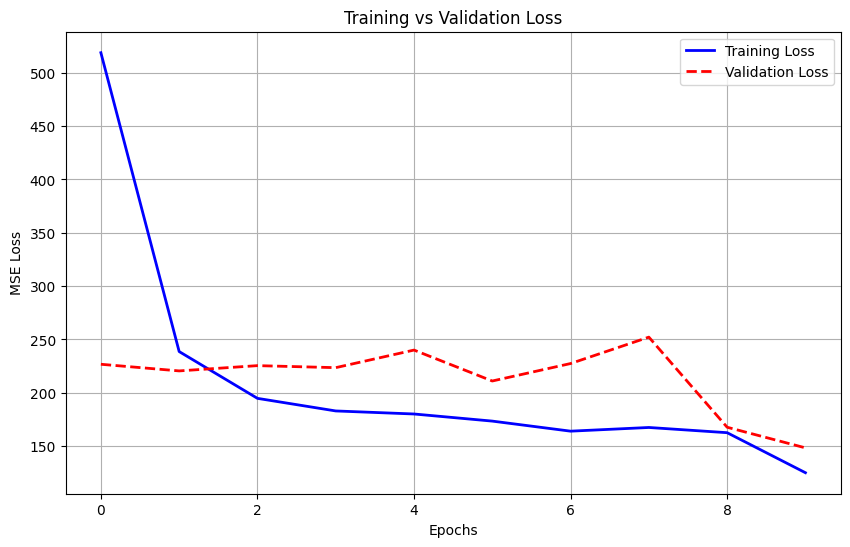

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(val_losses, label='Validation Loss', color='red', lw=2, linestyle='--')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# plot predicted versus true validation age distributions
fix, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

sns.histplot(age, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("Distribution of true age")
axes[0].set_xlabel("Age")

sns.histplot(outputs, kde=True, color='salmon', ax=axes[1])
axes[1].set_title("Distribution of predicted age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.savefig('/home/riritani/neuro_vfm/recon_dist.png', dpi=300, bbox_inches='tight')
plt.show()